In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score ,r2_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

In [ ]:
df = pd.read_excel('/content/Online+Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.isna().mean()

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.002683
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,0.249267
Country,0.000000


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().mean()

,0
InvoiceNo,0.0
StockCode,0.0
Description,0.0
Quantity,0.0
InvoiceDate,0.0
UnitPrice,0.0
CustomerID,0.0
Country,0.0


In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
le=LabelEncoder()
df['Description']=le.fit_transform(df['Description'])
df['Country']=le.fit_transform(df['Country'])

In [ ]:
df.drop(['InvoiceNo','InvoiceDate','CustomerID','StockCode'],axis=1,inplace=True)

In [ ]:
# 1. حساب إجمالي المبلغ لكل سطر (اختياري لكن مفيد جداً للـ Clustering)
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# 2. تحديد الأعمدة التي سنحسب لها الـ Z-score
cols_to_clean = ['Quantity', 'UnitPrice', 'TotalSum']

# 3. حساب Z-score
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df[cols_to_clean]))

# 4. الاحتفاظ بالصفوف التي تكون فيها القيم الشاذة ضمن النطاق المسموح (مثلاً أقل من 3 انحرافات)
df = df[(z_scores < 3).all(axis=1)]

print(f"البيانات الأصلية: {len(df)}")
print(f"البيانات بعد تنظيف الكميات والأسعار الشاذة: {len(df_clean)}")

البيانات الأصلية: 406341
البيانات بعد تنظيف الكميات والأسعار الشاذة: 406341


In [ ]:
s=StandardScaler()
df=s.fit_transform(df)

In [ ]:
pca=PCA(n_components=2)
df=pca.fit_transform(df)

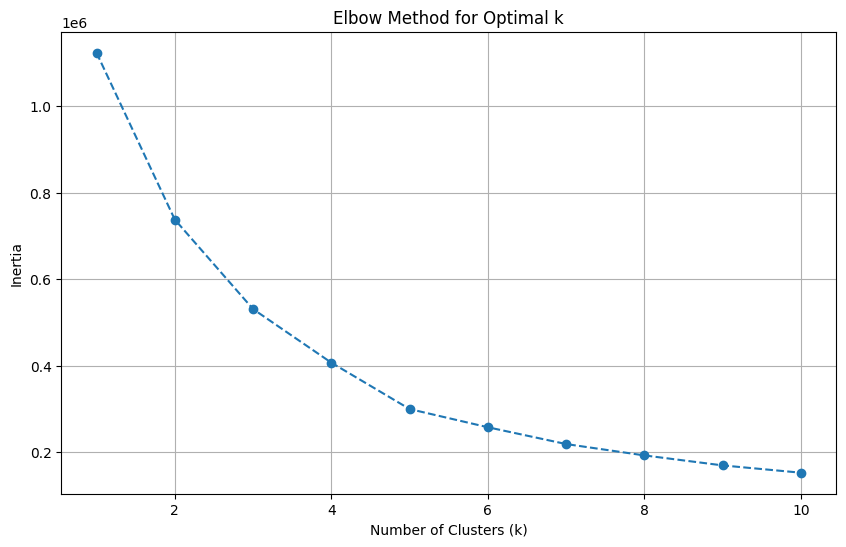

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# قائمة لتخزين قيم الـ Inertia (التباين داخل العناقيد)
inertia = []
K_range = range(1, 11)  # سنجرب من 1 إلى 10 عناقيد

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df) # استخدم البيانات الناتجة من الـ PCA التي رسمتها
    inertia.append(kmeans.inertia_)

# رسم مخطط الـ Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [ ]:
model=KMeans(n_clusters=3, random_state=42)
model.fit(df)

KMeans(n_clusters=3, random_state=42)

In [ ]:
pred=model.predict(df)

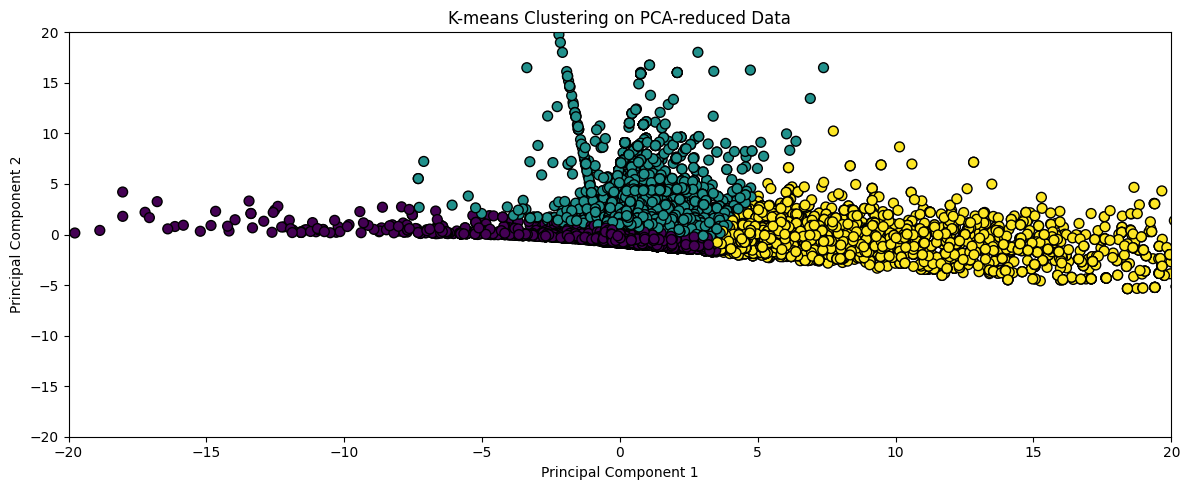

In [ ]:
plt.figure(figsize=(12, 5))
plt.scatter(df[:, 0], df[:, 1], c=pred, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('K-means Clustering on PCA-reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.xlim(-20,20)
plt.ylim(-20, 20)

plt.tight_layout()
plt.show()